In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def import_survey_data(path, sort=True):
    df = pd.read_csv(path, sep=';')
    if sort:
        df = df.sort_values(by=df.columns[1], ascending=False)

    category_names = df[df.columns[0]].tolist()
    results = {'Test':df[df.columns[1]].tolist()}
    return results, category_names


def aggregate_by_threshold(data_array, category_names, threshold_perc):
    if threshold_perc <= 0 or len(category_names) < 2:
        return data_array, category_names

    total_responses = data_array.sum()
    category_proportions = data_array.sum(axis=0) / total_responses * 100 
    merge_indices = np.where(category_proportions < threshold_perc)[0]
    
    if len(merge_indices) == 0:
        return data_array, category_names
    
    merged_data = data_array[:, merge_indices].sum(axis=1)
    kept_indices = [i for i in range(data_array.shape[1]) if i not in merge_indices]
    new_data = np.hstack((data_array[:, kept_indices], merged_data[:, np.newaxis]))
    new_category_names = [category_names[i] for i in kept_indices]
    new_category_names.append('Other')
    
    return new_data, new_category_names


def survey(results, category_names, global_font_size=12, label_n_cols=4,
           fig_size=(9.2, 5), threshold_perc=0, save_pdf=None,
           colors='RdYlGn_r', percentage_rotation=0, show_total_bracket=True):
    # Global font config
    font_family = "Times New Roman"
    plt.rcParams["font.family"] = font_family
    plt.rcParams["font.serif"] = [font_family]
    plt.rcParams["font.sans-serif"] = [font_family]
    plt.rcParams["font.size"] = global_font_size
    plt.rcParams['axes.edgecolor'] = '#333F4B'
    plt.rcParams['axes.linewidth'] = 0.8

    labels = list(results.keys())
    data = np.array(list(results.values()))

    data, category_names = aggregate_by_threshold(data, category_names, threshold_perc)
    total_counts = data.sum(axis=1).astype(int)

    data_sum = data.sum(axis=1)
    data_sum[data_sum == 0] = 1
    data = data / data_sum[:, np.newaxis] * 100
    data_cum = data.cumsum(axis=1)

    category_colors = plt.colormaps[colors](np.linspace(0.15, 0.85, data.shape[1]))

    fig, ax = plt.subplots(figsize=fig_size, dpi=300)
    ax.invert_yaxis()
    ax.xaxis.set_visible(False)
    ax.set_xlim(0, 100)
    ax.set_yticklabels([])
    ax.tick_params(axis='y', length=0)
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False)

    for i, (colname, color) in enumerate(zip(category_names, category_colors)):
        widths = data[:, i]
        starts = data_cum[:, i] - widths
        rects = ax.barh(labels, widths, left=starts, height=0.5, label=colname, color=color)
        ax.bar_label(rects, label_type='center', color='black',
                     fmt='%.1f%%', fontsize=global_font_size * 0.65,
                     rotation=percentage_rotation, fontfamily=font_family)

    ax.legend(ncols=label_n_cols, bbox_to_anchor=(0, 1.05), loc='lower left',
              fontsize='small', frameon=False, handlelength=0.9, handleheight=0.9)

    if show_total_bracket:
        bar_height = 0.5
        inset = 0.1  # space from bar end to bracket start
        x0, x1 = inset, 100 - inset
        stem = 0.12
        color = "#000000"
        y_offset = 0.14  # distance below bar center

        for idx, _ in enumerate(labels):
            y_base = idx + bar_height/2 + y_offset  # below the bar
            ax.plot([x0, x1], [y_base, y_base], color=color, lw=0.5, clip_on=False)
            ax.plot([x0, x0], [y_base, y_base - stem], color=color, lw=0.5, clip_on=False)
            ax.plot([x1, x1], [y_base, y_base - stem], color=color, lw=0.5, clip_on=False)
            ax.text((x0 + x1) / 2, y_base,  # text on the bracket line
                    f'{total_counts[idx]} | 100%',
                    ha='center', va='center',
                    fontsize=global_font_size * 0.65,  # match in-bar labels
                    fontname=font_family,
                    color=color,
                    bbox=dict(facecolor='white', edgecolor='white', pad=0.4))

    if save_pdf is not None:
        plt.savefig('../figures/' + save_pdf + '.pdf', bbox_inches='tight')
    plt.show()


def survey_donut(results, category_names, global_font_size=12, label_n_cols=2,
                 fig_size=(5, 5), threshold_perc=0, save_pdf=None,
                 colors='RdYlGn_r', start_angle=90):
    # Global font config
    font_family = "Times New Roman"
    plt.rcParams["font.family"] = font_family
    plt.rcParams["font.serif"] = [font_family]
    plt.rcParams["font.sans-serif"] = [font_family]
    plt.rcParams["font.size"] = global_font_size
    plt.rcParams['axes.edgecolor'] = '#333F4B'
    plt.rcParams['axes.linewidth'] = 0.8

    labels = list(results.keys())
    data = np.array(list(results.values()))  # shape (1, n)

    # Aggregate (same as bar version)
    data, category_names = aggregate_by_threshold(data, category_names, threshold_perc)

    counts = data.flatten()
    total = counts.sum()
    if total == 0:
        total = 1  # avoid div-by-zero
    percentages = counts / total * 100

    # Colors
    cmap = plt.colormaps[colors]
    color_list = cmap(np.linspace(0.15, 0.85, len(category_names)))

    fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
    radius = 0.6  # overall size of the donut
    width = 0.30  # thickness of the ring

    wedges, _ = ax.pie(
        counts,
        labels=None,
        colors=color_list,
        startangle=start_angle,
        counterclock=False,
        radius=radius,
        wedgeprops=dict(width=width, edgecolor='white')
    )

    for w, pct in zip(wedges, percentages):
        if pct < 1e-2:
            continue
        ang = (w.theta2 + w.theta1) / 2
        label_r = radius - width / 2  # center of the ring
        x = np.cos(np.deg2rad(ang)) * label_r
        y = np.sin(np.deg2rad(ang)) * label_r
        ax.text(x, y, f'{pct:.1f}%',
                ha='center', va='center',
                fontsize=global_font_size * 0.65,
                fontname=font_family, color='#333F4B')

    # Legend
    ax.legend(wedges, category_names, ncols=label_n_cols,
              bbox_to_anchor=(0.5, 0.25), loc='upper center',
              fontsize='small', frameon=False, handlelength=1.0, handleheight=1.0)

    # Center text (total and 100%)
    ax.text(0, 0, f'{int(total)}\n100%',
            ha='center', va='center',
            fontsize=global_font_size*0.75,
            fontname=font_family, color='#333F4B')

    ax.set(aspect="equal")
    fig.subplots_adjust(left=0.00, right=0.5, top=0.5, bottom=0.00) 
    if save_pdf is not None:
        plt.savefig('../figures/donut_' + save_pdf + '.pdf', bbox_inches='tight', pad_inches=0.0)
    plt.show()


colormaps = {
    "Diverging": [
        "PuOr",
        "BrBG",
        "seismic",
        "RdYlGn"
    ],
    "Sequential": [
        "viridis",
        "Blues",
        "magma"
    ],
    "Qualitative": [
        "tab10",
        "Paired",
        "Dark2"
    ]
}

filepath = '../data/derived/'
paper_column = 'double'  # 'single' or 'double' (10.5, 0.2)

if paper_column == 'single':
    fig_size_default = (10.5, 0.2)
    percentage_rotation_default = 0
    global_font_size_default = 12
else:
    fig_size_default = (5.25, 0.8)
    percentage_rotation_default = 90
    global_font_size_default = 14


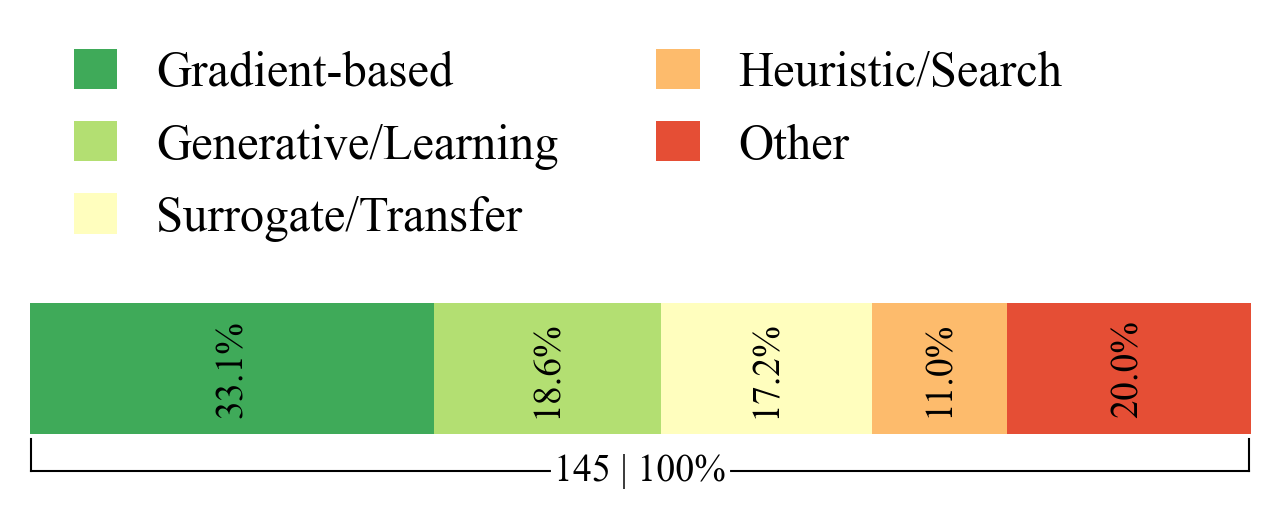

In [2]:
filename = 'attack_technique'
results, category_names = import_survey_data(filepath + filename + '.csv')

survey(
    results, 
    category_names, 
    label_n_cols=2, 
    fig_size=fig_size_default, 
    threshold_perc=10, 
    save_pdf=filename,
    percentage_rotation=percentage_rotation_default,
    global_font_size=global_font_size_default)

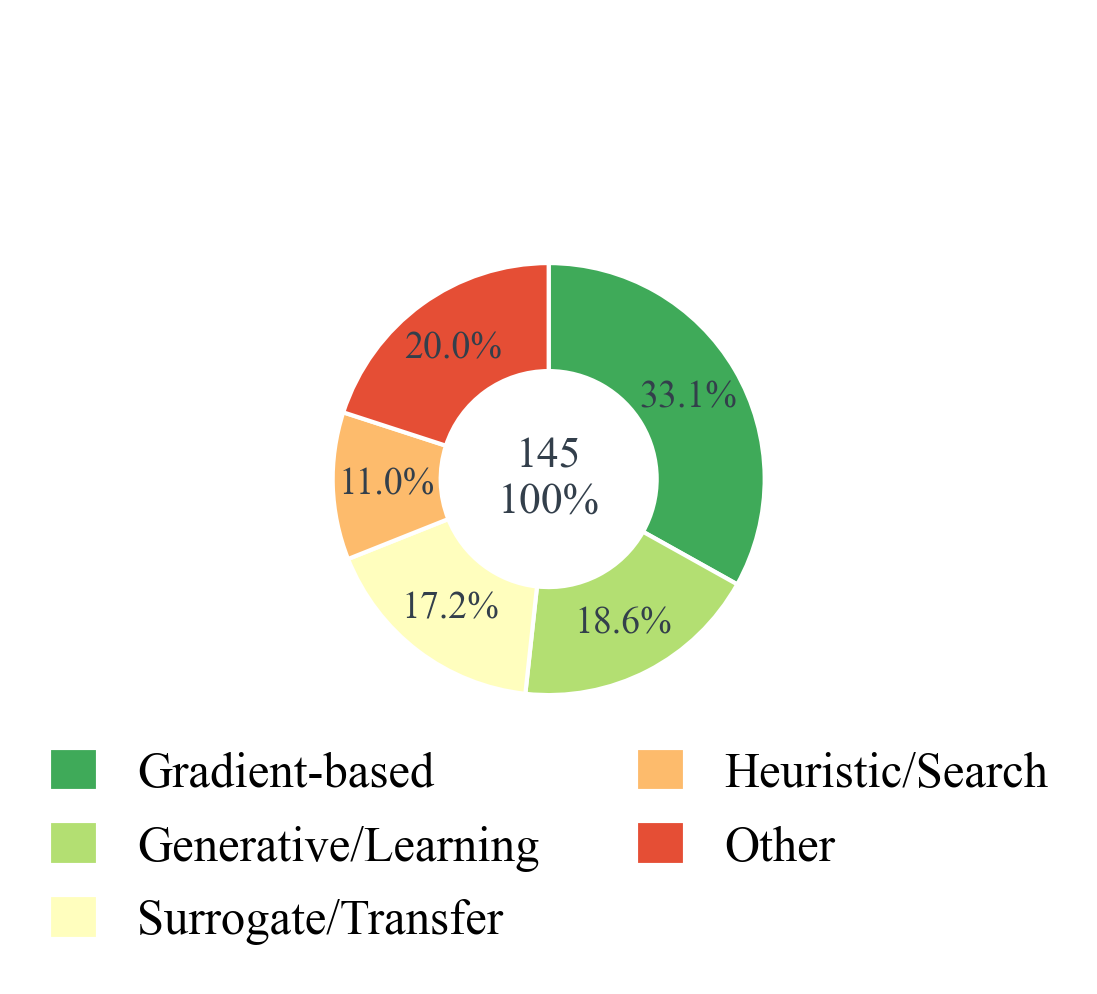

In [3]:
survey_donut(
    results, 
    category_names, 
    label_n_cols=2, 
    fig_size=fig_size_default, 
    threshold_perc=10, 
    save_pdf=filename,
    global_font_size=global_font_size_default)

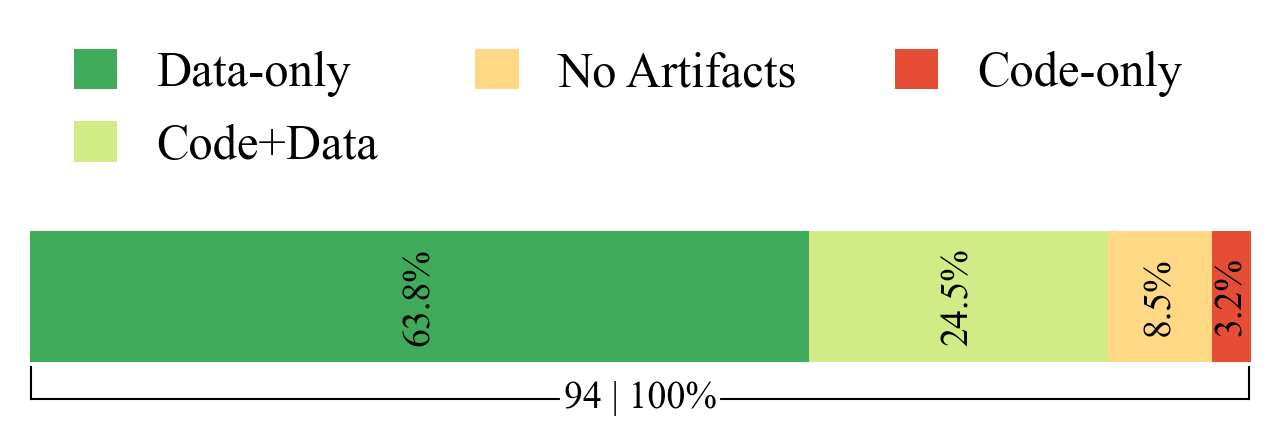

In [4]:
filename = 'code_data'
results, category_names = import_survey_data(filepath + filename + '.csv')

survey(
    results, 
    category_names, 
    label_n_cols=3, 
    fig_size=fig_size_default, 
    threshold_perc=0, 
    save_pdf=filename,
    percentage_rotation=percentage_rotation_default,
    global_font_size=global_font_size_default)

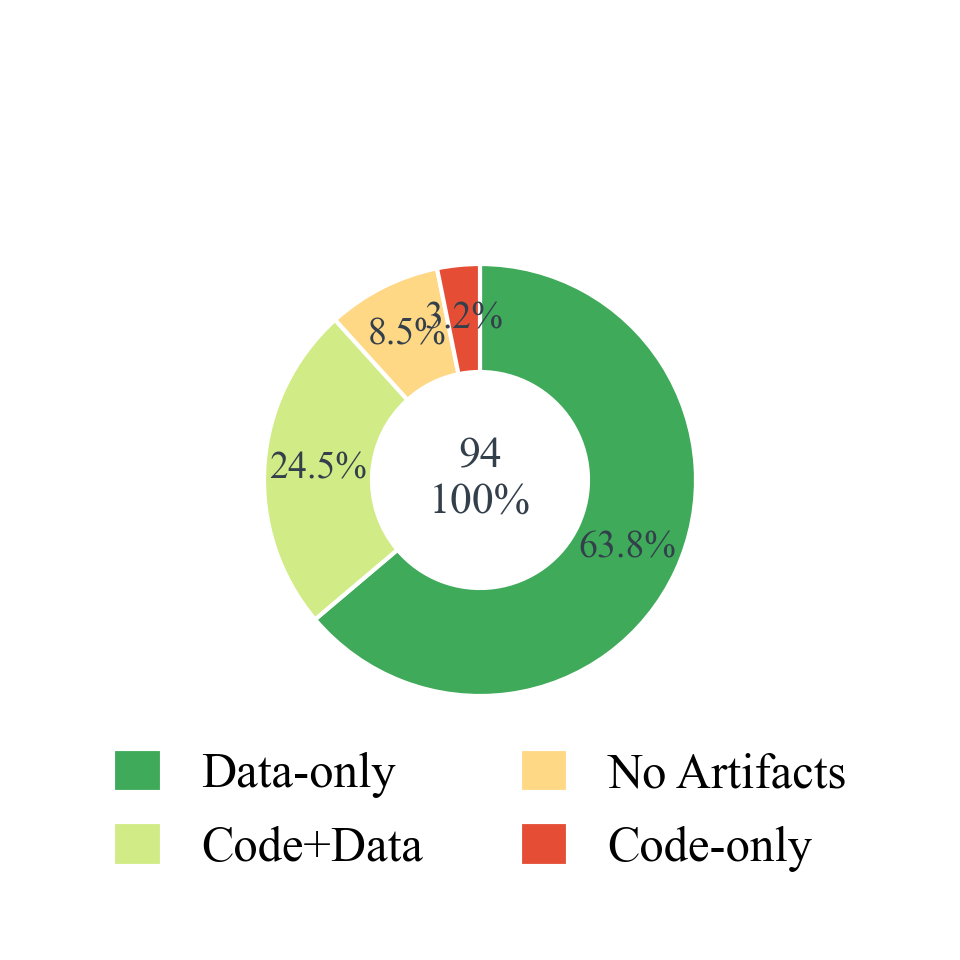

In [5]:
survey_donut(
    results, 
    category_names, 
    label_n_cols=2, 
    fig_size=fig_size_default, 
    threshold_perc=0, 
    save_pdf=filename,
    global_font_size=global_font_size_default)

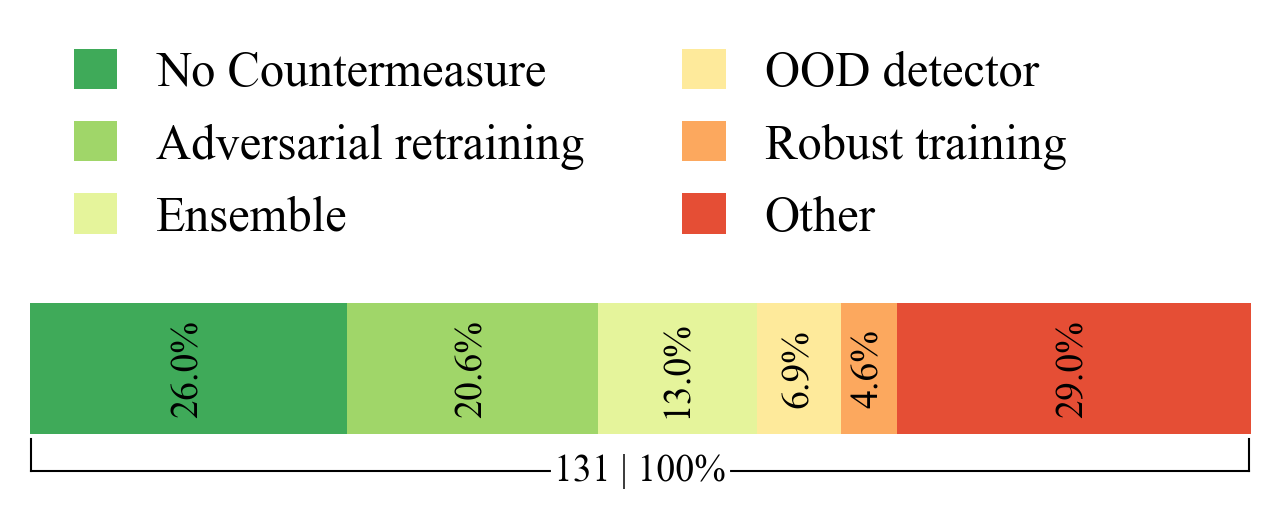

In [6]:
filename = 'defense_technique'
results, category_names = import_survey_data(filepath + filename + '.csv')

survey(
    results, 
    category_names, 
    label_n_cols=2, 
    fig_size=fig_size_default, 
    threshold_perc=4, 
    save_pdf=filename,
    percentage_rotation=percentage_rotation_default,
    global_font_size=global_font_size_default)

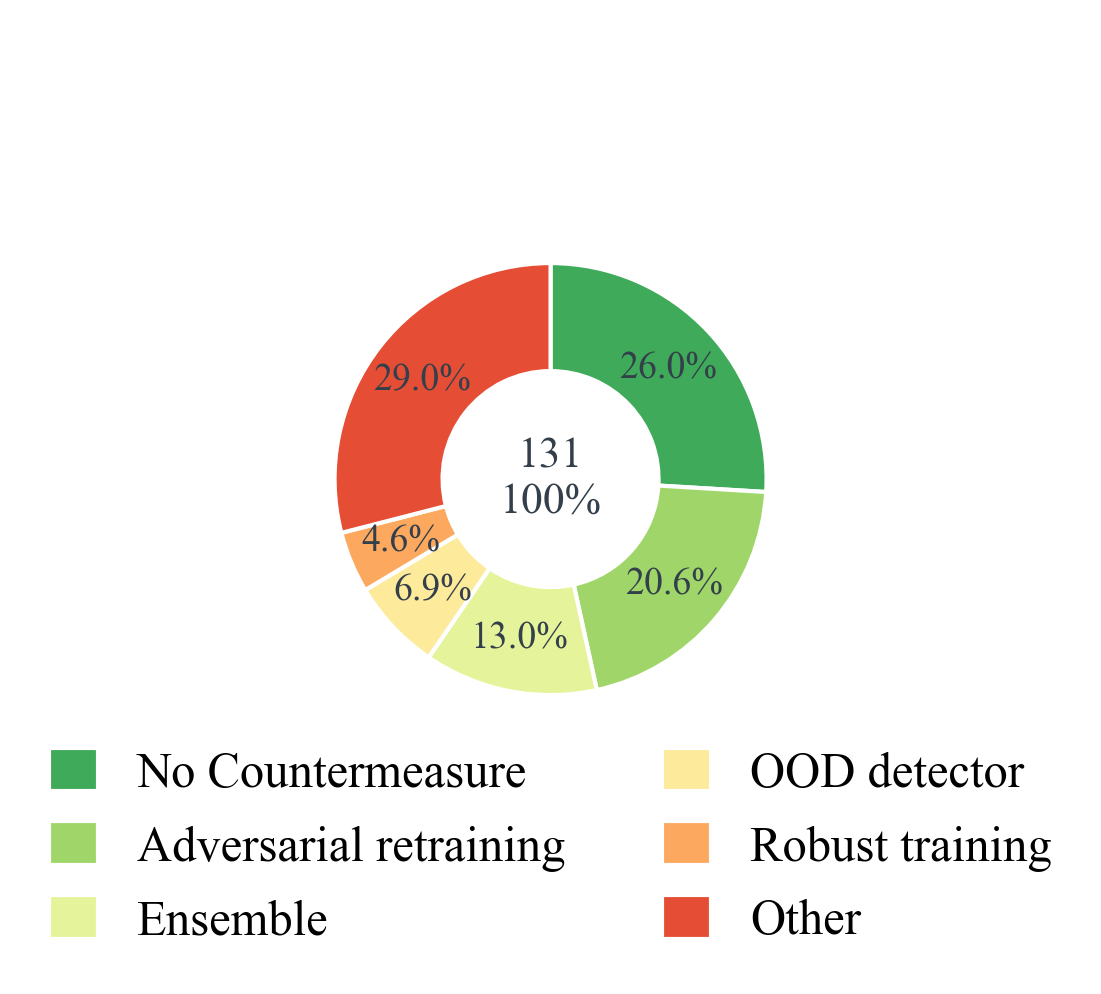

In [7]:
survey_donut(
    results, 
    category_names, 
    label_n_cols=2, 
    fig_size=fig_size_default, 
    threshold_perc=4, 
    save_pdf=filename,
    global_font_size=global_font_size_default)

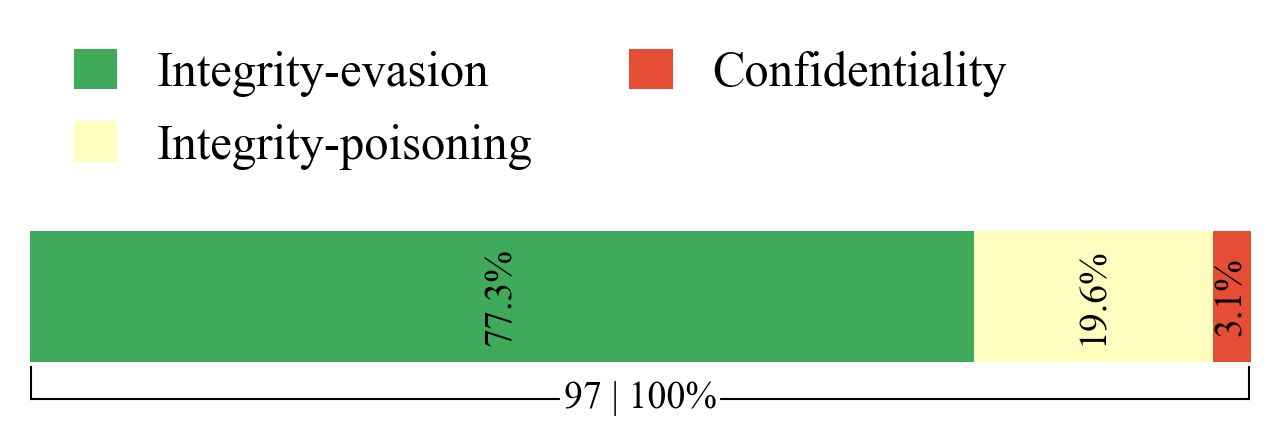

In [8]:
filename = 'goal'
results, category_names = import_survey_data(filepath + filename + '.csv')
survey(
    results, 
    category_names, 
    label_n_cols=2, 
    fig_size=fig_size_default, 
    threshold_perc=0, 
    save_pdf=filename,
    percentage_rotation=percentage_rotation_default,
    global_font_size=global_font_size_default)

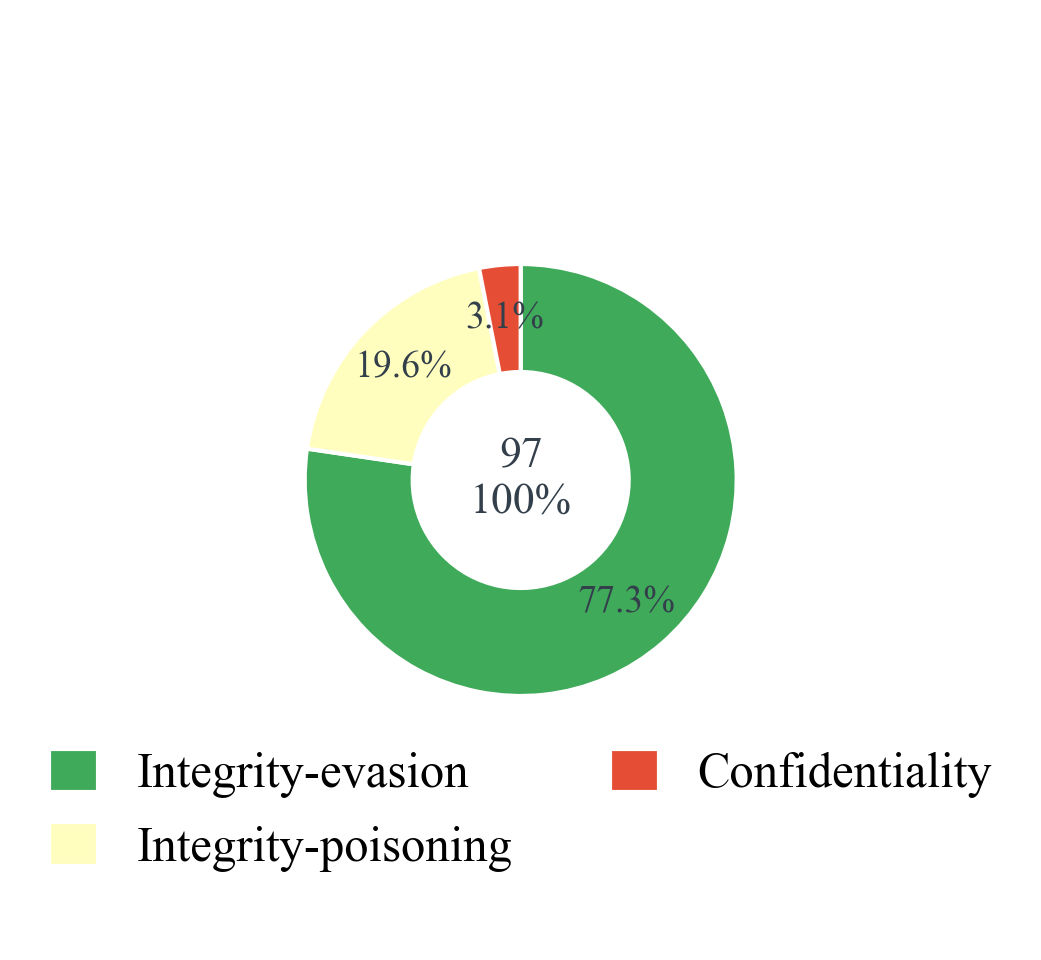

In [9]:
survey_donut(
    results, 
    category_names, 
    label_n_cols=2, 
    fig_size=fig_size_default, 
    threshold_perc=0, 
    save_pdf=filename,
    global_font_size=global_font_size_default)

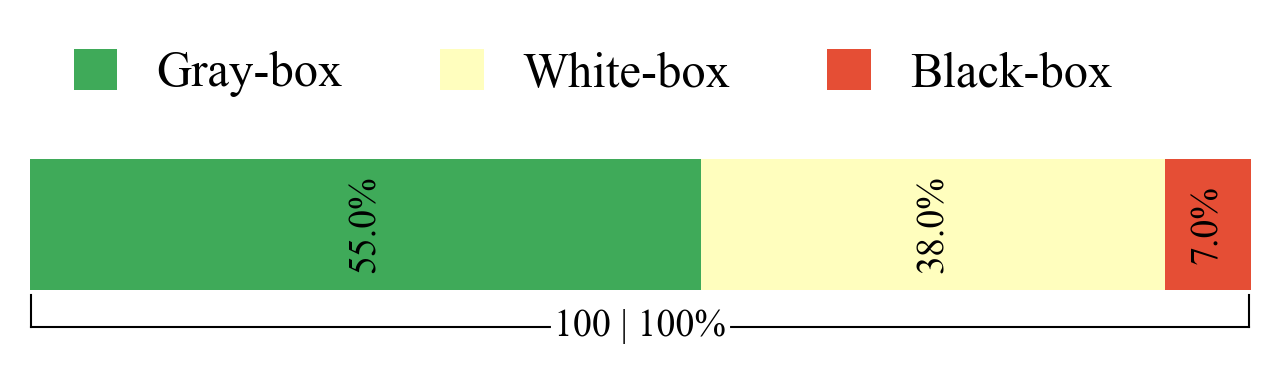

In [10]:
filename = 'knowledge'
results, category_names = import_survey_data(filepath + filename + '.csv')
survey(
    results, 
    category_names, 
    label_n_cols=6, 
    fig_size=fig_size_default, 
    threshold_perc=0, 
    save_pdf=filename,
    percentage_rotation=percentage_rotation_default,
    global_font_size=global_font_size_default)

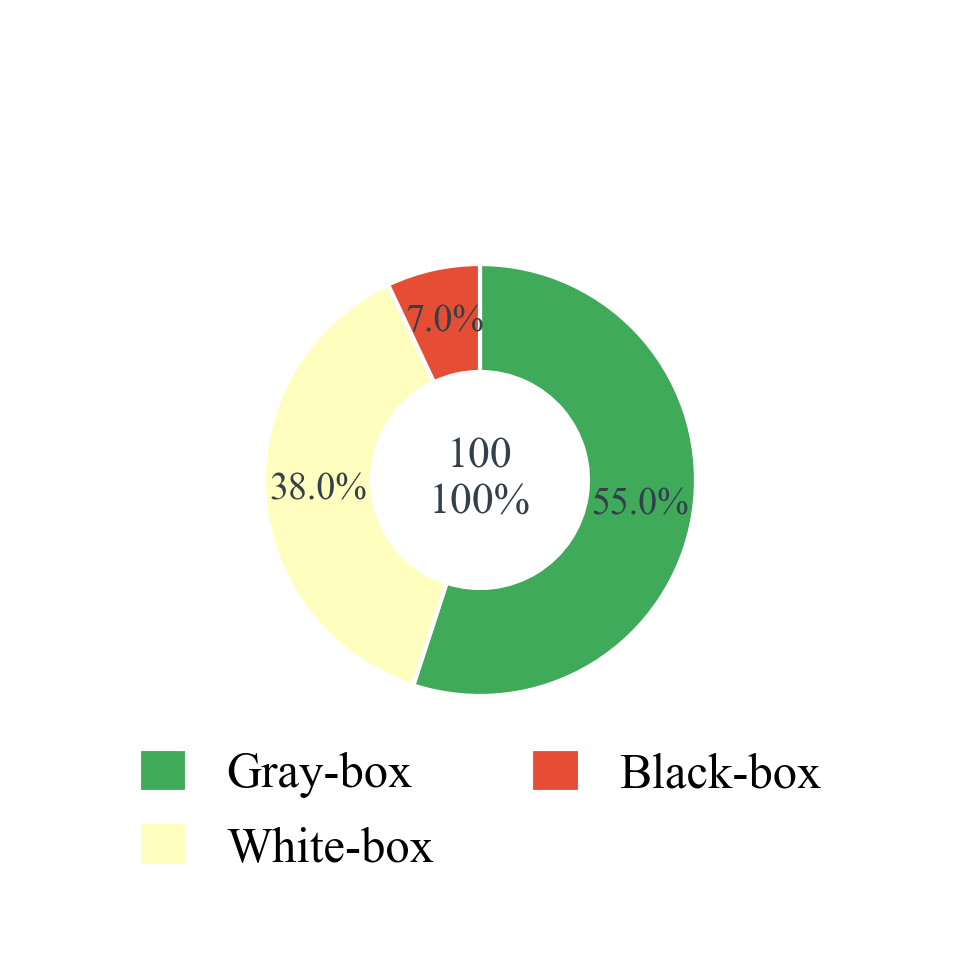

In [11]:
survey_donut(
    results, 
    category_names, 
    label_n_cols=2, 
    fig_size=fig_size_default, 
    threshold_perc=0, 
    save_pdf=filename,
    global_font_size=global_font_size_default)

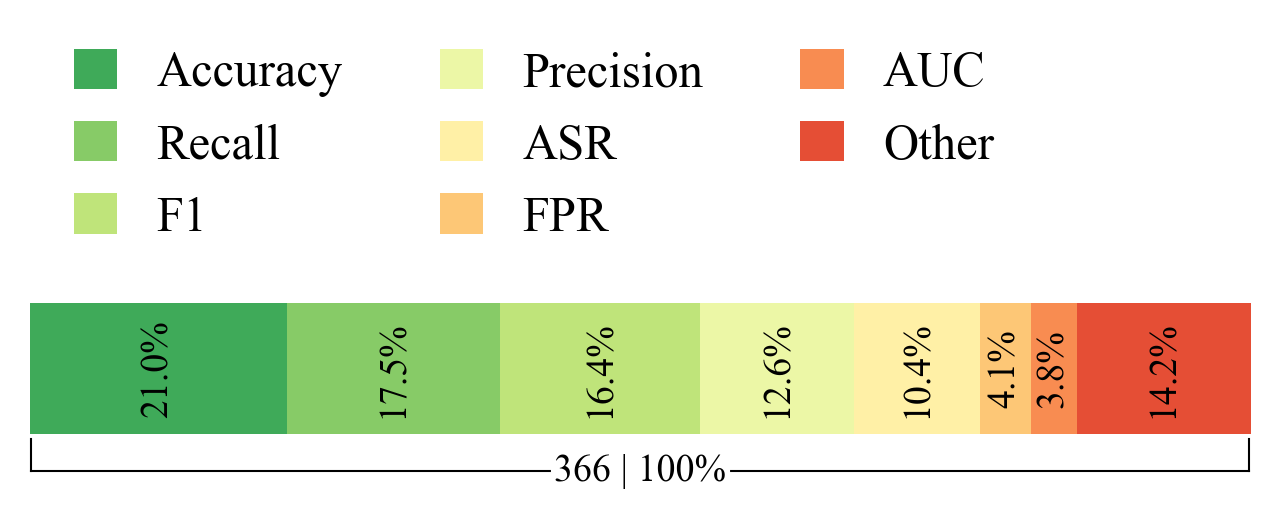

In [12]:
filename = 'metrics'
results, category_names = import_survey_data(filepath + filename + '.csv') 
survey(
    results, 
    category_names, 
    label_n_cols=3, 
    fig_size=fig_size_default, 
    threshold_perc=3, 
    save_pdf=filename,
    percentage_rotation=percentage_rotation_default,
    global_font_size=global_font_size_default)

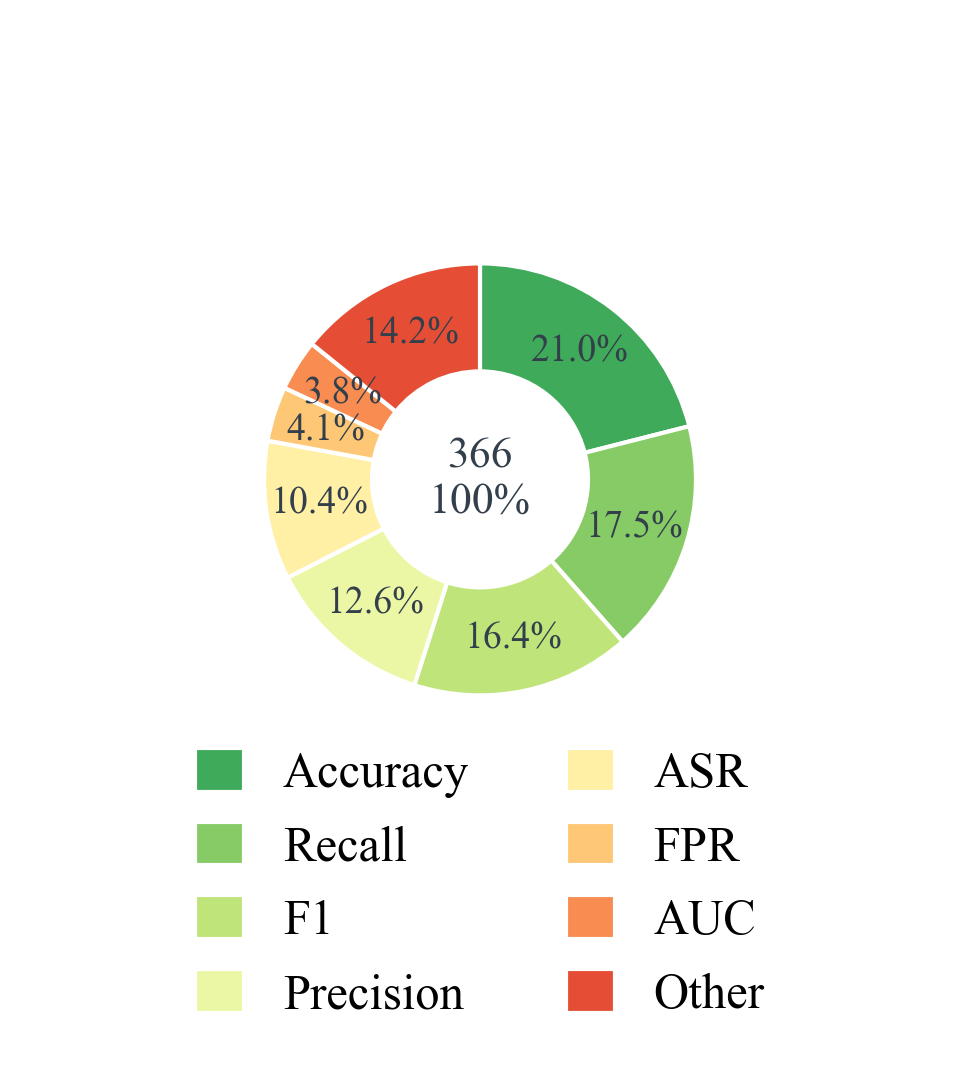

In [13]:
survey_donut(
    results, 
    category_names, 
    label_n_cols=2, 
    fig_size=fig_size_default, 
    threshold_perc=3, 
    save_pdf=filename,
    global_font_size=global_font_size_default)

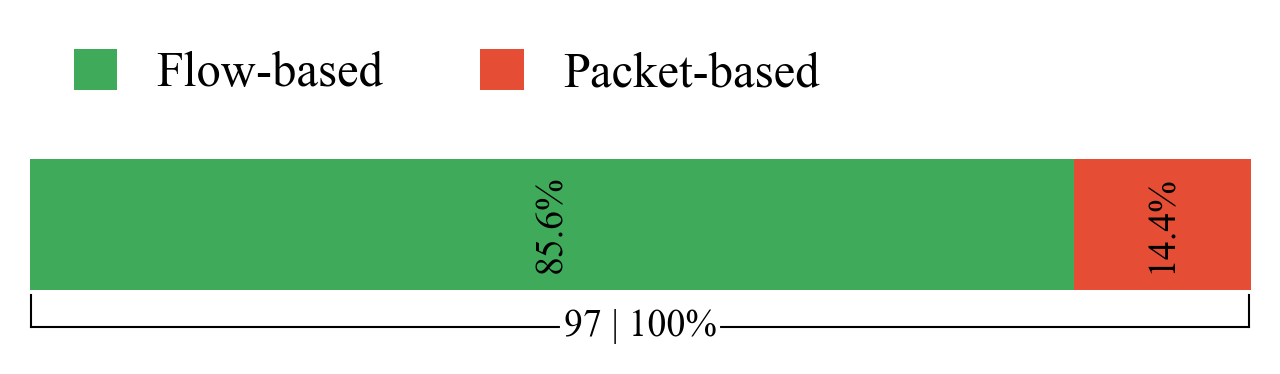

In [14]:
filename = 'nids_granularity'
results, category_names = import_survey_data(filepath + filename + '.csv') # This line should be outside the survey function

survey(
    results, 
    category_names, 
    label_n_cols=6, 
    fig_size=fig_size_default, 
    threshold_perc=0, 
    save_pdf=filename,
    percentage_rotation=percentage_rotation_default,
    global_font_size=global_font_size_default)

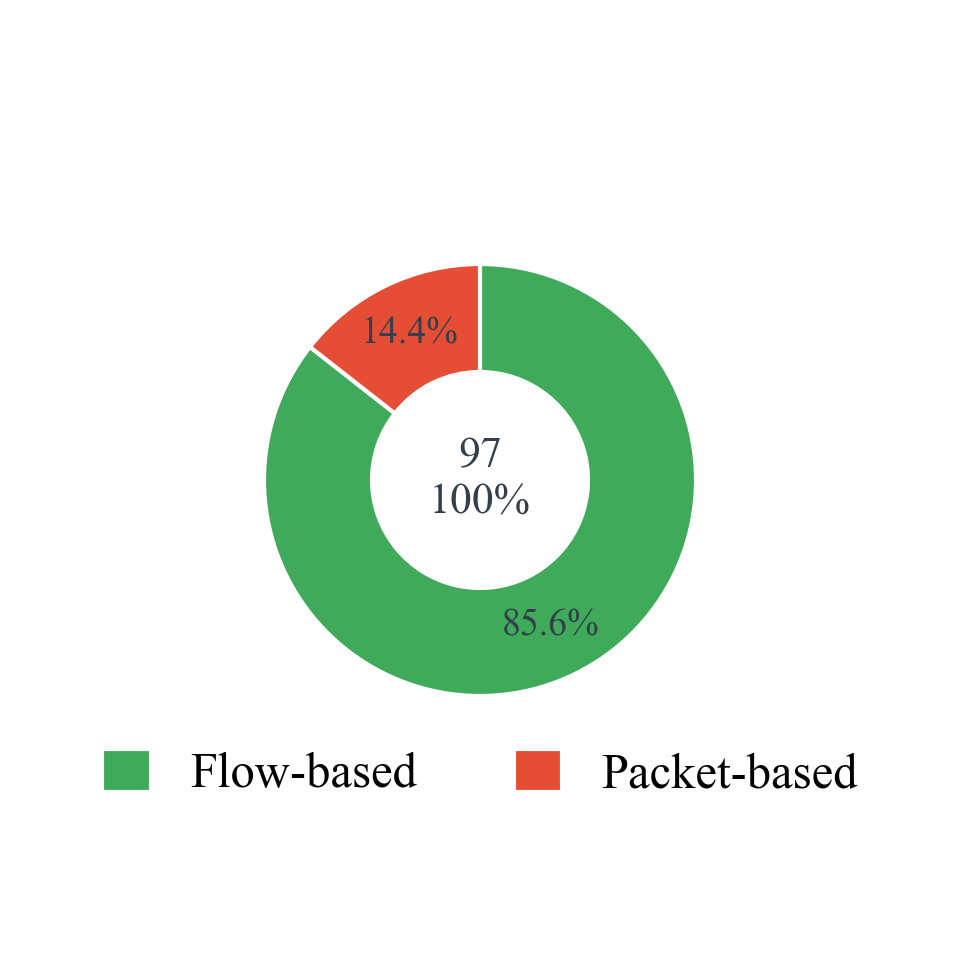

In [15]:
survey_donut(
    results, 
    category_names, 
    label_n_cols=6, 
    fig_size=fig_size_default, 
    threshold_perc=0, 
    save_pdf=filename,
    global_font_size=global_font_size_default)

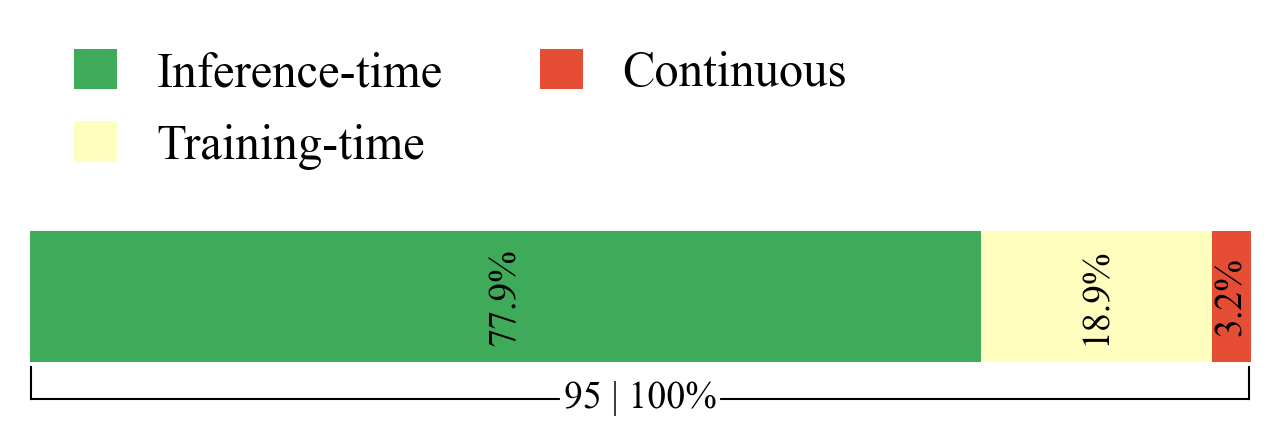

In [16]:
filename = 'phase'
results, category_names = import_survey_data(filepath + filename + '.csv') # This line should be outside the survey function

survey(
    results, 
    category_names, 
    label_n_cols=2, 
    fig_size=fig_size_default, 
    threshold_perc=0, 
    save_pdf=filename,
    percentage_rotation=percentage_rotation_default,
    global_font_size=global_font_size_default)

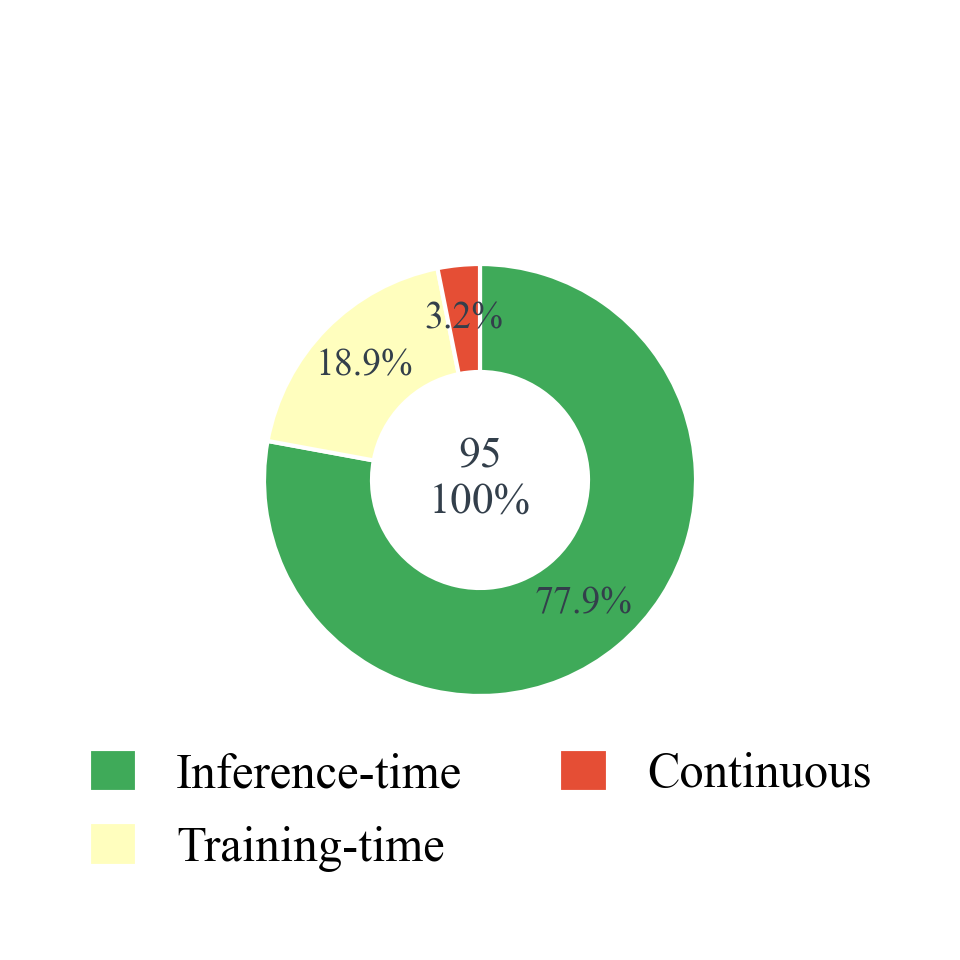

In [17]:
survey_donut(
    results, 
    category_names, 
    label_n_cols=2, 
    fig_size=fig_size_default, 
    threshold_perc=0, 
    save_pdf=filename,
    global_font_size=global_font_size_default)

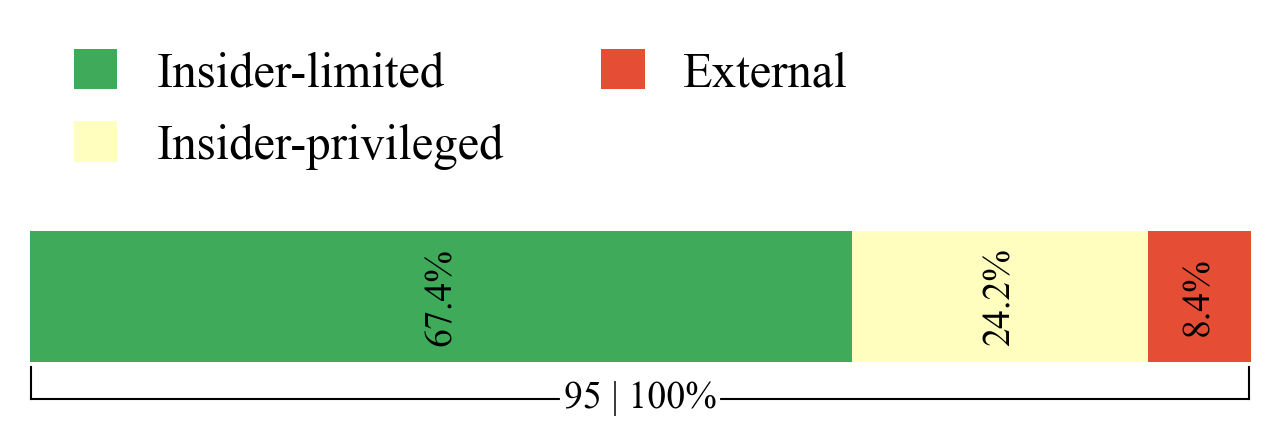

In [18]:
filename = 'position'
results, category_names = import_survey_data(filepath + filename + '.csv') # This line should be outside the survey function

survey(
    results, 
    category_names, 
    label_n_cols=2, 
    fig_size=fig_size_default, 
    threshold_perc=0, 
    save_pdf=filename,
    percentage_rotation=percentage_rotation_default,
    global_font_size=global_font_size_default)

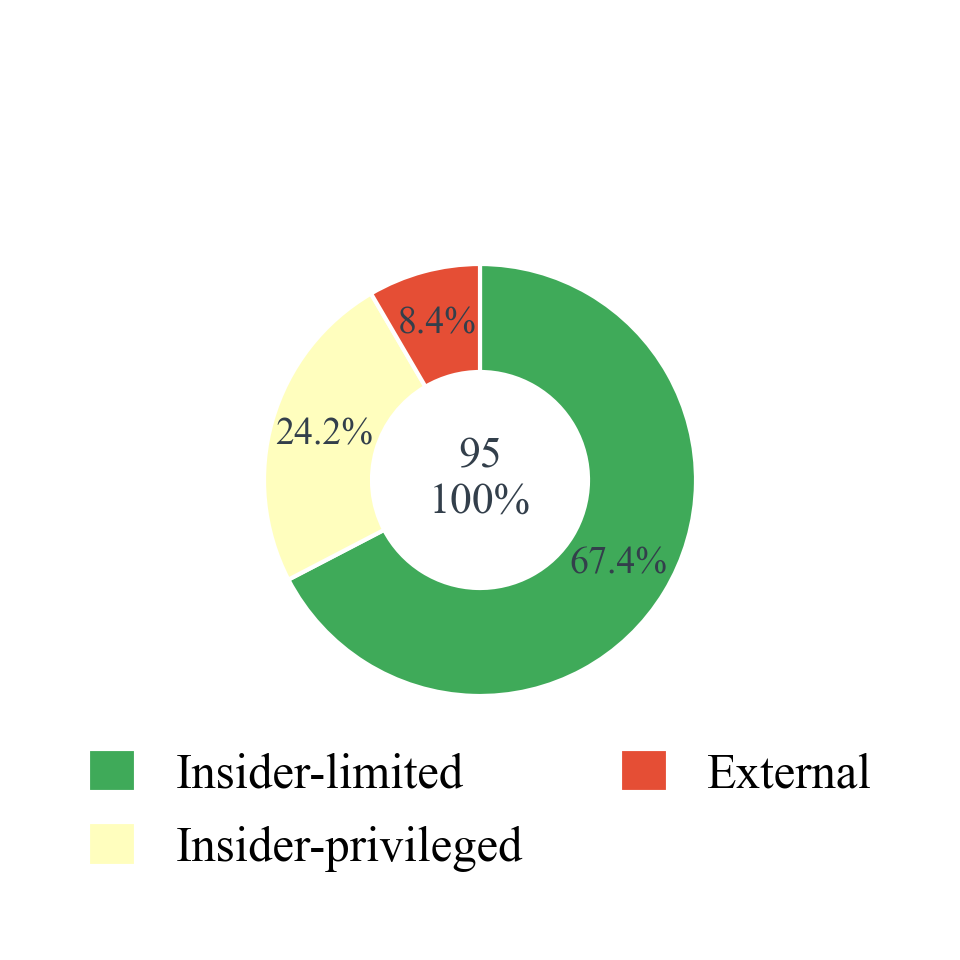

In [19]:
survey_donut(
    results, 
    category_names, 
    label_n_cols=2, 
    fig_size=fig_size_default, 
    threshold_perc=0, 
    save_pdf=filename,
    global_font_size=global_font_size_default)

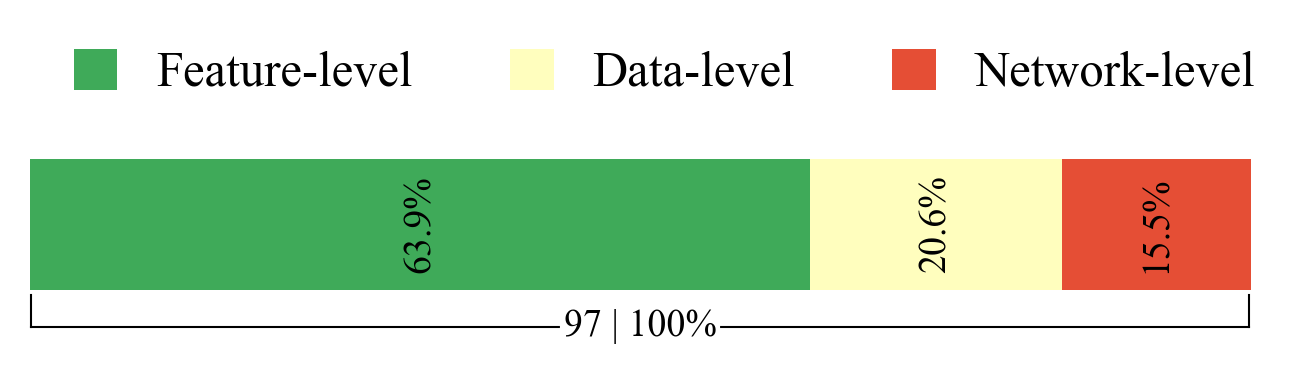

In [20]:
filename = 'surface'
results, category_names = import_survey_data(filepath + filename + '.csv') # This line should be outside the survey function

survey(
    results, 
    category_names, 
    label_n_cols=6, 
    fig_size=fig_size_default, 
    threshold_perc=0, 
    save_pdf=filename,
    percentage_rotation=percentage_rotation_default,
    global_font_size=global_font_size_default)

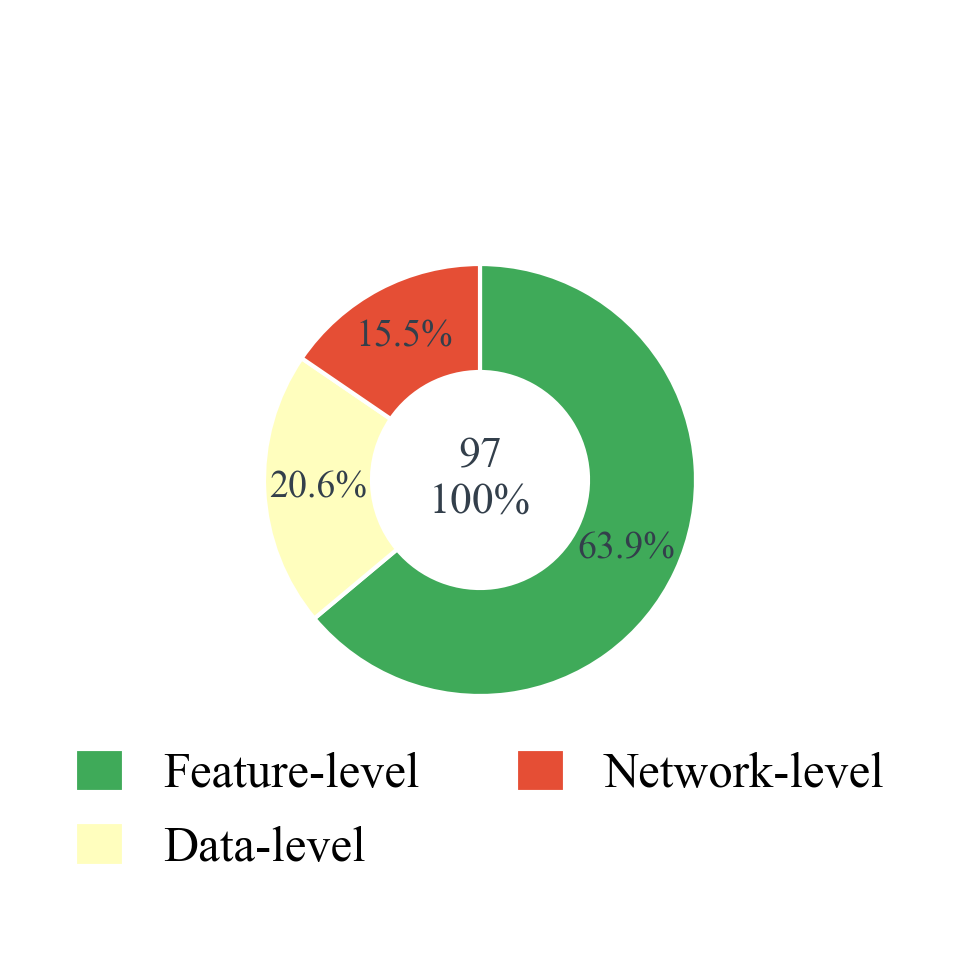

In [21]:
survey_donut(
    results, 
    category_names, 
    label_n_cols=2, 
    fig_size=fig_size_default, 
    threshold_perc=0, 
    save_pdf=filename,
    global_font_size=global_font_size_default)

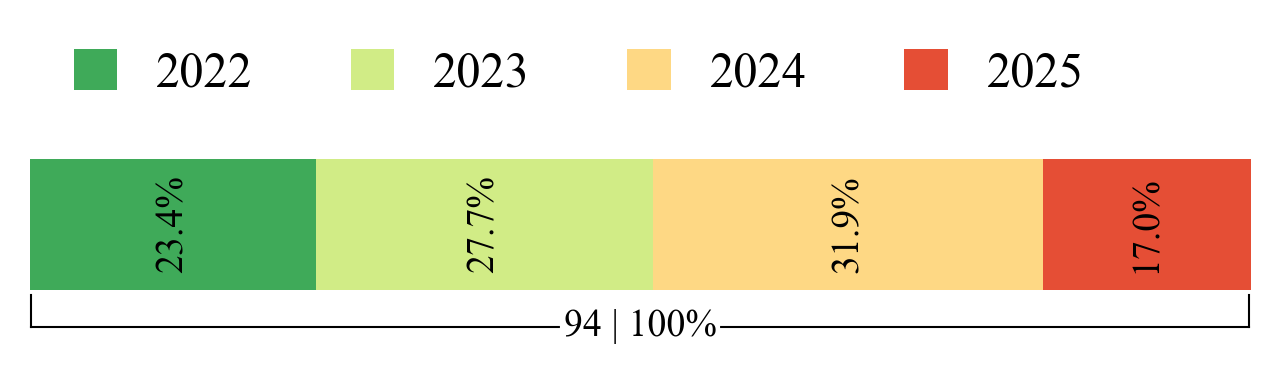

In [22]:
filename = 'year'
results, category_names = import_survey_data(filepath + filename + '.csv', sort=False) # This line should be outside the survey function

survey(
    results, 
    category_names, 
    label_n_cols=6, 
    fig_size=fig_size_default, 
    threshold_perc=0, 
    save_pdf=filename,
    percentage_rotation=percentage_rotation_default,
    global_font_size=global_font_size_default)

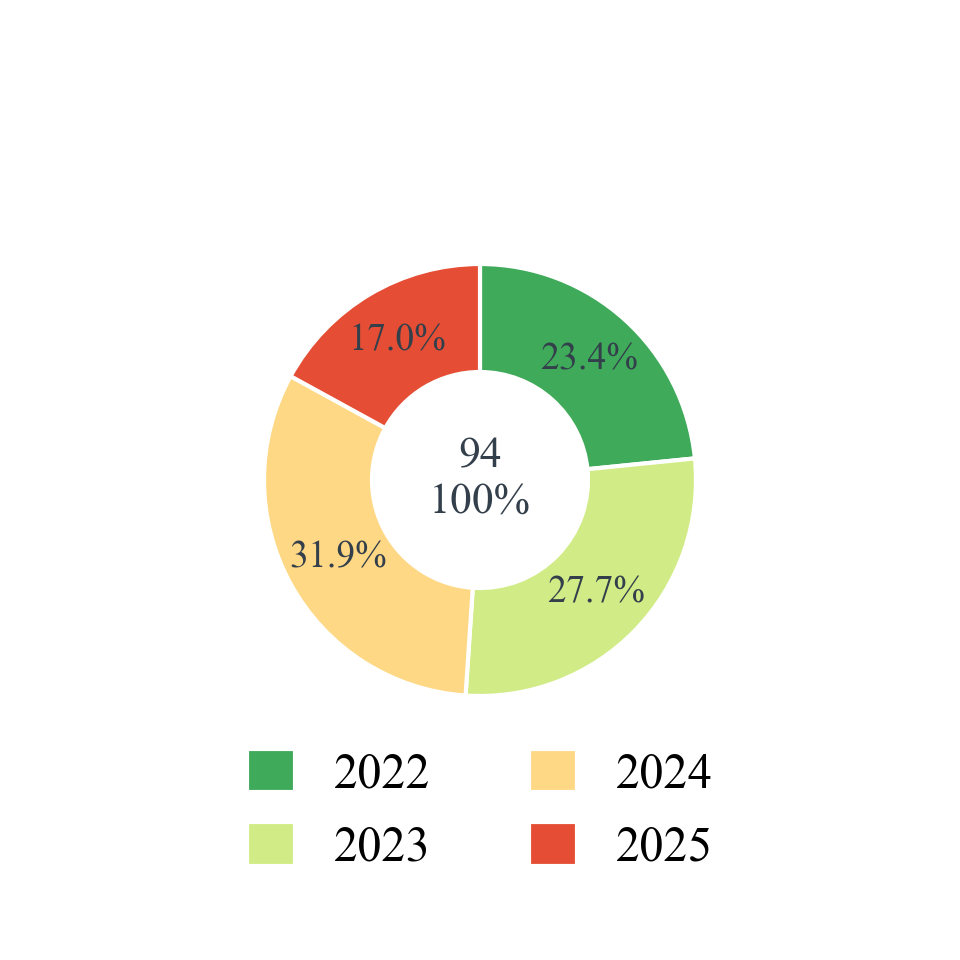

In [23]:
survey_donut(
    results, 
    category_names, 
    label_n_cols=2, 
    fig_size=fig_size_default, 
    threshold_perc=0, 
    save_pdf=filename,
    global_font_size=global_font_size_default)

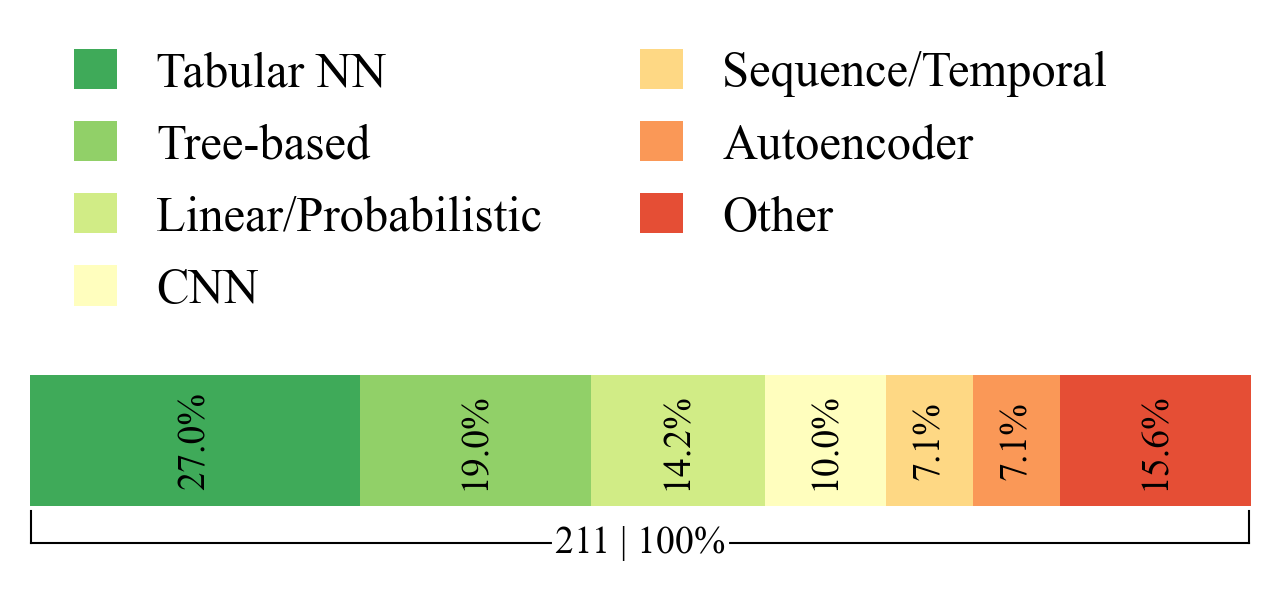

In [24]:
filename = 'models'
results, category_names = import_survey_data(filepath + filename + '.csv', sort=False) # This line should be outside the survey function

survey(
    results, 
    category_names, 
    label_n_cols=2, 
    fig_size=fig_size_default, 
    threshold_perc=6, 
    save_pdf=filename,
    percentage_rotation=percentage_rotation_default,
    global_font_size=global_font_size_default)

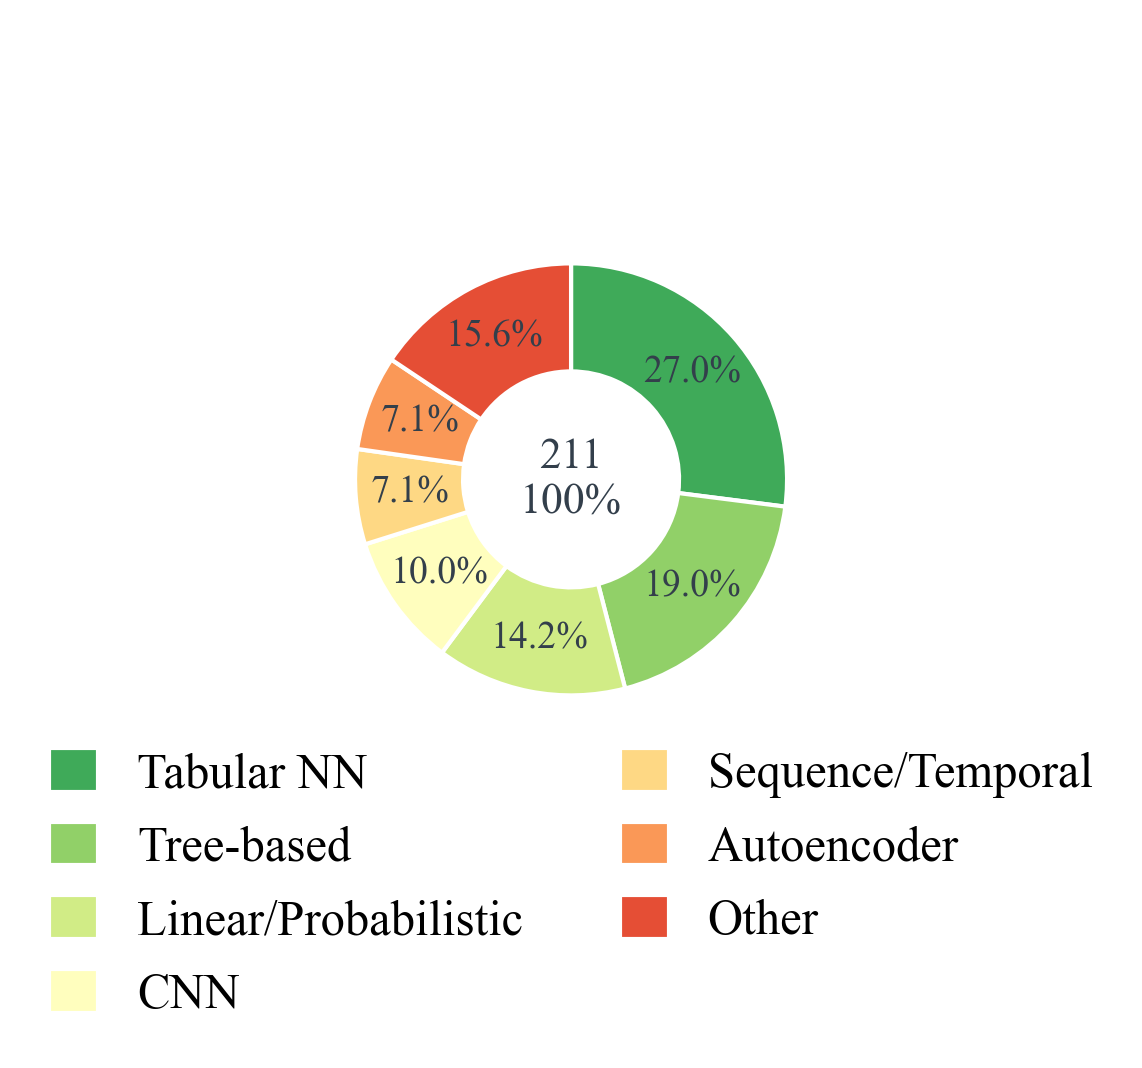

In [25]:
survey_donut(
    results, 
    category_names, 
    label_n_cols=2, 
    fig_size=fig_size_default, 
    threshold_perc=6, 
    save_pdf=filename,
    global_font_size=global_font_size_default)

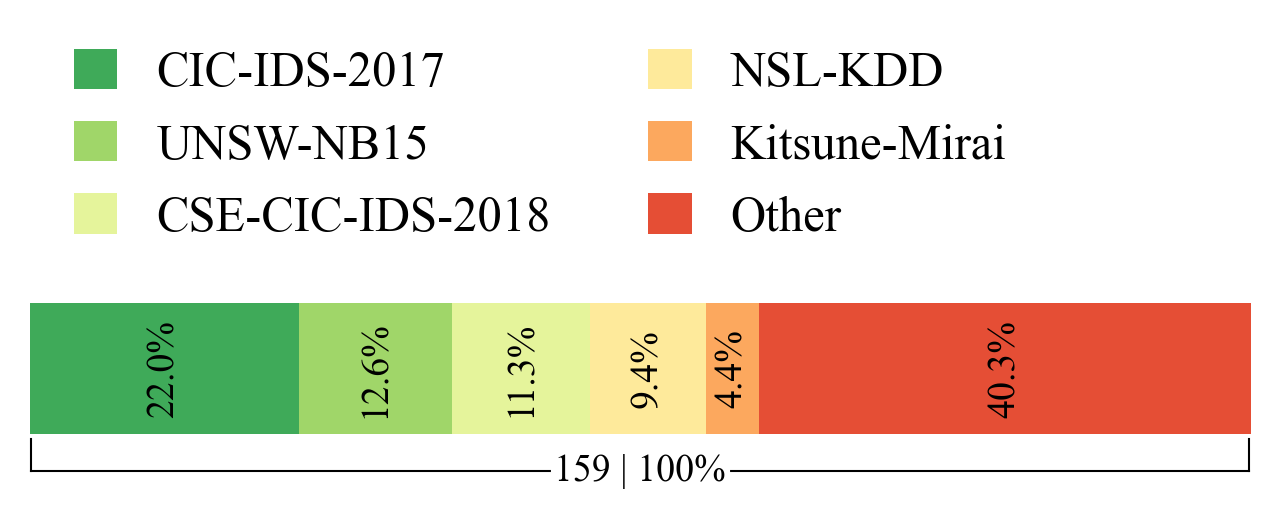

In [26]:
filename = 'datasets'
results, category_names = import_survey_data(filepath + filename + '.csv', sort=True) # This line should be outside the survey function

survey(
    results, 
    category_names, 
    label_n_cols=2, 
    fig_size=fig_size_default, 
    threshold_perc=4, 
    save_pdf=filename,
    percentage_rotation=percentage_rotation_default,
    global_font_size=global_font_size_default)

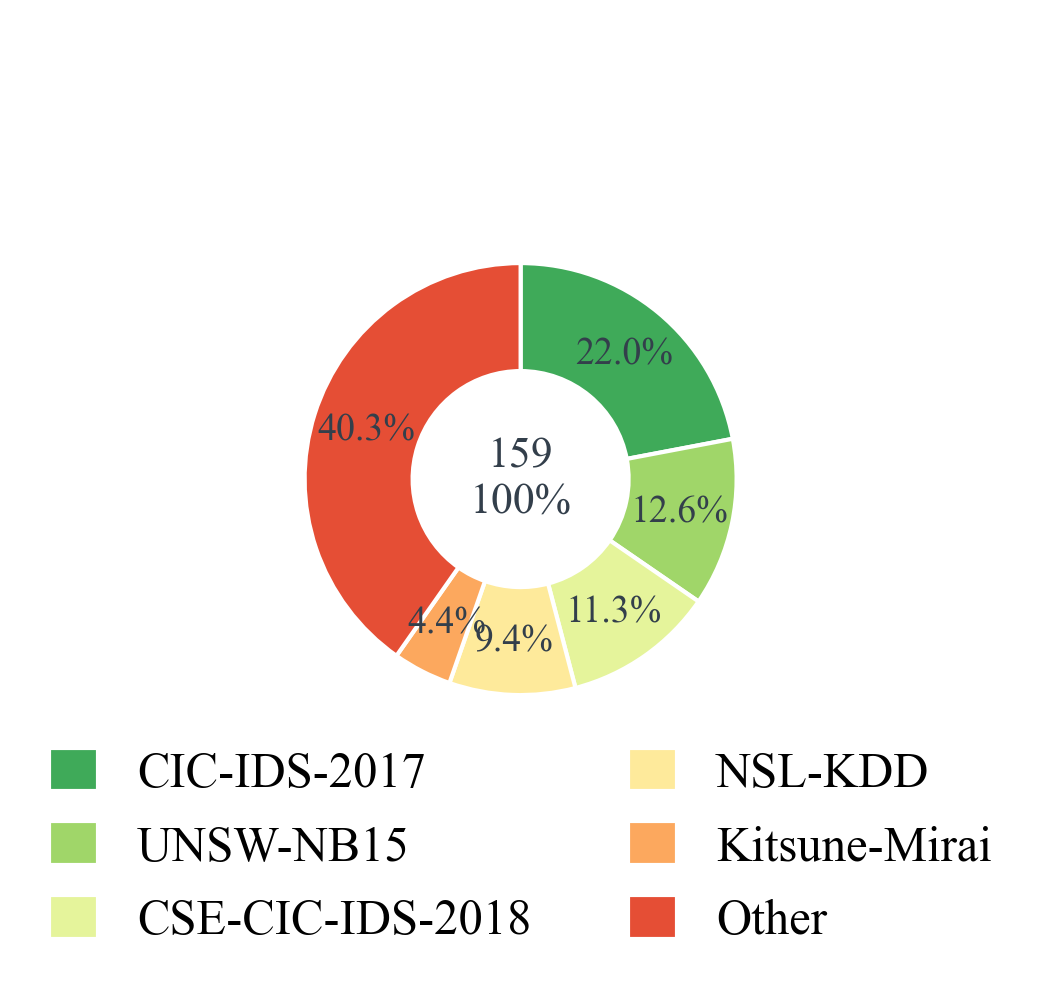

In [27]:
survey_donut(
    results, 
    category_names, 
    label_n_cols=2, 
    fig_size=fig_size_default, 
    threshold_perc=4, 
    save_pdf=filename,
    global_font_size=global_font_size_default)